# Model-Predictive Control with Random Shooting

KinDER environments expose `get_state`, `set_state`, and `get_next_state`
methods that let you simulate the environment without committing to actions.
This makes them suitable for model-based planning techniques.

This notebook demonstrates the simplest such technique: **random-shooting MPC**.
At each real step we sample many random action sequences, simulate each one
forward using `get_next_state`, score the results, and execute only the first
action of the best sequence. Then we re-plan from the new state.

In [ ]:
%pip install kindergarden[kinematic2d]
# Other available extras: dynamic2d, kinematic3d, dynamic3d
# Or install everything: %pip install kindergarden[all]

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import kinder

## Setup

We use `Motion2D-p0` (no obstacles) so the task is pure navigation to a goal
region. The key argument is `allow_state_access=True`, which unlocks
`get_state`, `set_state`, and `get_next_state`.

Observation shape: (19,)
Action shape:      (5,)


pybullet build time: Dec 21 2025 15:26:53
/Users/tom/kindergarden/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/tom/kindergarden/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


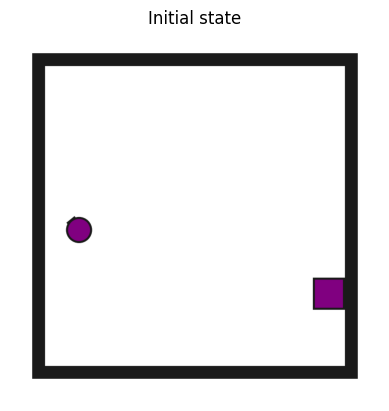

In [2]:
kinder.register_all_environments()

env = kinder.make(
    "kinder/Motion2D-p0-v0",
    render_mode="rgb_array",
    allow_state_access=True,
)
obs, info = env.reset(seed=42)

# kinder.make() wraps the environment in gymnasium wrappers.
# Access the unwrapped env to use the state interface.
unwrapped = env.unwrapped

print("Observation shape:", env.observation_space.shape)
print("Action shape:     ", env.action_space.shape)

plt.imshow(env.render())
plt.axis("off")
plt.title("Initial state")
plt.show()

## Cost Function

The observation vector starts with the robot's `(x, y)` at indices 0–1 and
the target region's `(x, y)` at indices 9–10. We score a trajectory by the
Euclidean distance from the robot to the target at its final state.

In [3]:
def cost(state: np.ndarray) -> float:
    """Euclidean distance from robot to target region center."""
    robot_xy = state[:2]
    target_xy = state[9:11]
    return float(np.linalg.norm(robot_xy - target_xy))

## Random-Shooting MPC

Each planning step:
1. Save the current state with `get_state`.
2. Sample `num_candidates` random action sequences of length `horizon`.
3. For each candidate, roll out the sequence using `get_next_state` and
   evaluate the cost of the final state.
4. Restore the real state with `set_state` and execute the first action of
   the best candidate.

In [4]:
num_candidates = 50
horizon = 5
max_steps = 300
rng = np.random.default_rng(0)

obs, info = env.reset(seed=42)
frames = [env.render()]

for step in range(max_steps):
    current_state = unwrapped.get_state()

    # Sample random action sequences (only dx, dy matter; zero out the rest).
    raw = rng.uniform(
        low=env.action_space.low[:2],
        high=env.action_space.high[:2],
        size=(num_candidates, horizon, 2),
    ).astype(np.float32)
    action_sequences = np.zeros(
        (num_candidates, horizon, env.action_space.shape[0]), dtype=np.float32
    )
    action_sequences[:, :, :2] = raw

    # Evaluate each candidate by simulating forward.
    best_cost = float("inf")
    best_idx = 0
    for i in range(num_candidates):
        state = current_state
        for t in range(horizon):
            state = unwrapped.get_next_state(state, action_sequences[i, t])
        c = cost(state)
        if c < best_cost:
            best_cost = c
            best_idx = i

    # Restore the real state and execute the best first action.
    unwrapped.set_state(current_state)
    obs, reward, terminated, truncated, info = env.step(action_sequences[best_idx, 0])
    frames.append(env.render())

    if terminated or truncated:
        print(f"Reached goal in {step + 1} steps!")
        break
else:
    print(f"Did not reach goal within {max_steps} steps (final cost: {cost(obs):.3f}).")

Reached goal in 87 steps!


## Visualize the Result

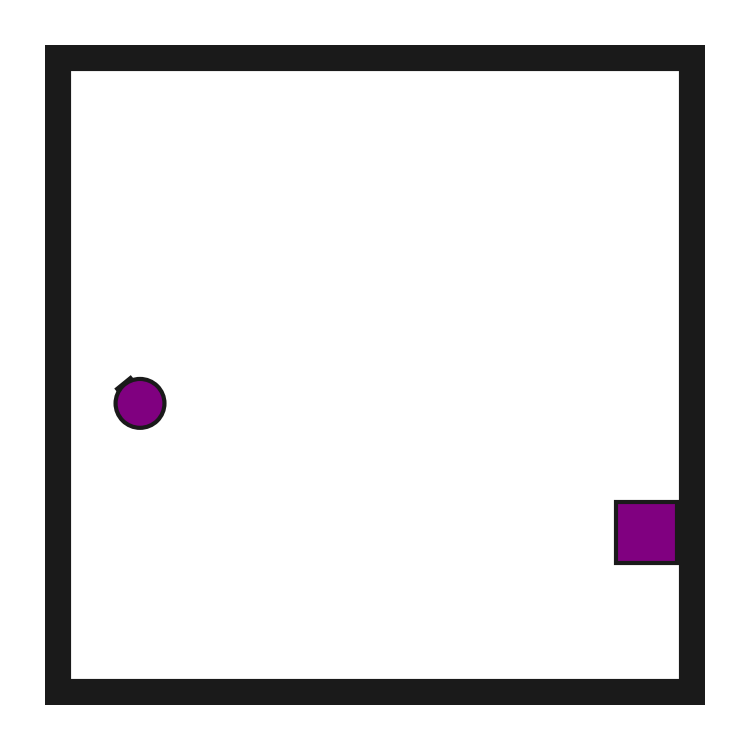

In [5]:
from io import BytesIO

from IPython.display import Image
from PIL import Image as PILImage

pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Cleanup

In [6]:
env.close()